# D20 – Student Dropout Prediction
**Goal:** D20 – Student Dropout Prediction

**Models:** XGBoost · LightGBM · CatBoost · GradientBoosting

**Dataset:** `student_dropout.csv`

In [1]:
import os
os.chdir(r'c:\Users\Raj singh senger\Downloads\Projects')
print('Working directory:', os.getcwd())

Working directory: c:\Users\Raj singh senger\Downloads\Projects


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings, pickle, os
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score)
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.figsize': (12,5), 'figure.dpi': 100, 'axes.titlesize': 13})
pd.set_option('display.max_columns', 50)
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Section 1 – Load & Explore Dataset

In [3]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 1 : LOAD DATASET
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = pd.read_csv(r'D20_Student_Dropout_Prediction/data set/student_dropout.csv')
print("="*60)
print(f"Dataset Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage   : {df.memory_usage(deep=True).sum()/1024:.1f} KB")
print("="*60)
print("\n📌 First 5 rows:")
display(df.head())
print("\n📌 Last 5 rows:")
display(df.tail())
print("\n📌 Random 5 rows:")
display(df.sample(5, random_state=42))
print("\n📌 Column names:")
print(list(df.columns))

Dataset Shape  : 10000 rows × 17 columns
Memory Usage   : 2719.6 KB

📌 First 5 rows:


,student_id,age_at_enrollment,gender,marital_status,scholarship_holder,debtor,tuition_fees_up_to_date,curricular_units_sem1_enrolled,curricular_units_sem1_approved,curricular_units_sem2_enrolled,curricular_units_sem2_approved,gpa_sem1,gpa_sem2,family_income_inr,attendance_pct,failed_courses,dropout
0,STU00001,25.000000,Male,Divorced,0.0,0.0,1.0,4.0,3.0,0.0,0.0,15.20,8.68,576069.0,63.45,0.0,-2.021557
1,STU00002,-3.727199,Male,Single,NaN,0.0,1.0,5.0,4.0,1.0,0.0,11.66,18.77,685739.0,24.48,1.0,0.000000
2,STU00003,26.000000,Female,Single,1.0,0.0,1.0,2.0,2.0,8.0,8.0,13.46,12.55,311099.0,80.67,2.0,0.000000
3,STU00004,30.000000,Male,Single,0.0,NaN,1.0,0.0,0.0,0.0,0.0,9.56,10.68,72059.0,94.96,4.0,1.000000
4,STU00005,27.000000,Female,Single,0.0,0.0,1.0,8.0,8.0,0.0,0.0,9.81,14.71,168503.0,82.48,5.0,1.000000



📌 Last 5 rows:


,student_id,age_at_enrollment,gender,marital_status,scholarship_holder,debtor,tuition_fees_up_to_date,curricular_units_sem1_enrolled,curricular_units_sem1_approved,curricular_units_sem2_enrolled,curricular_units_sem2_approved,gpa_sem1,gpa_sem2,family_income_inr,attendance_pct,failed_courses,dropout
9995,STU09996,26.0,Male,Single,4.026589,0.0,0.0,7.0,4.0,8.000000,5.0,10.49,13.91,451337.0,68.14,5.000000,1.0
9996,STU09997,30.0,Female,Married,0.000000,0.0,1.0,2.0,0.0,8.000000,8.0,12.24,18.74,NaN,70.88,5.000000,1.0
9997,STU09998,29.0,Male,Married,0.000000,1.0,1.0,4.0,2.0,20.136993,0.0,7.43,11.44,50000.0,NaN,3.000000,1.0
9998,STU09999,31.0,Female,Widowed,1.000000,0.0,1.0,4.0,2.0,1.000000,0.0,20.00,7.00,276036.0,57.91,-4.614406,0.0
9999,STU10000,17.0,Female,Single,1.000000,1.0,1.0,8.0,NaN,7.000000,6.0,15.14,9.94,91355.0,66.29,3.000000,1.0



📌 Random 5 rows:


,student_id,age_at_enrollment,gender,marital_status,scholarship_holder,debtor,tuition_fees_up_to_date,curricular_units_sem1_enrolled,curricular_units_sem1_approved,curricular_units_sem2_enrolled,curricular_units_sem2_approved,gpa_sem1,gpa_sem2,family_income_inr,attendance_pct,failed_courses,dropout
6252,STU06253,24.0,Female,Single,0.0,0.0,1.000000,7.0,6.0,5.000000,2.0,15.71,11.46000,437737.0,72.91,1.0,0.0
4684,STU04685,21.0,Male,Married,0.0,1.0,1.000000,3.0,3.0,5.000000,NaN,12.70,40.84894,813175.0,90.65,NaN,1.0
1731,STU01732,20.0,Female,Single,0.0,0.0,0.000000,3.0,0.0,9.000000,7.0,18.35,17.23000,641589.0,56.28,5.0,1.0
4742,STU04743,29.0,Male,Married,1.0,0.0,3.323966,5.0,2.0,-16.694429,8.0,17.17,10.10000,50000.0,71.17,0.0,0.0
4521,STU04522,23.0,Male,Married,1.0,0.0,0.000000,5.0,3.0,5.000000,3.0,15.30,13.08000,69105.0,56.85,3.0,0.0



📌 Column names:
['student_id', 'age_at_enrollment', 'gender', 'marital_status', 'scholarship_holder', 'debtor', 'tuition_fees_up_to_date', 'curricular_units_sem1_enrolled', 'curricular_units_sem1_approved', 'curricular_units_sem2_enrolled', 'curricular_units_sem2_approved', 'gpa_sem1', 'gpa_sem2', 'family_income_inr', 'attendance_pct', 'failed_courses', 'dropout']


---
## 🔍 Section 2 – Data Types & Overview

In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 2 : DATA TYPES & OVERVIEW
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📌 Data Types:")
print(df.dtypes.to_string())

print("\n📌 Dataset Info:")
df.info()

num_cols  = df.select_dtypes(include=np.number).columns.tolist()
cat_cols  = df.select_dtypes(include='object').columns.tolist()
print(f"\nNumeric columns  ({len(num_cols)}): {num_cols}")
print(f"Categorical cols ({len(cat_cols)}): {cat_cols}")

print("\n📌 Numerical Statistics:")
display(df.describe().round(3))

if cat_cols:
    print("\n📌 Categorical Statistics:")
    display(df.describe(include='object'))

📌 Data Types:
student_id                         object
age_at_enrollment                 float64
gender                             object
marital_status                     object
scholarship_holder                float64
debtor                            float64
tuition_fees_up_to_date           float64
curricular_units_sem1_enrolled    float64
curricular_units_sem1_approved    float64
curricular_units_sem2_enrolled    float64
curricular_units_sem2_approved    float64
gpa_sem1                          float64
gpa_sem2                          float64
family_income_inr                 float64
attendance_pct                    float64
failed_courses                    float64
dropout                           float64

📌 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   student_id          

,age_at_enrollment,scholarship_holder,debtor,tuition_fees_up_to_date,curricular_units_sem1_enrolled,curricular_units_sem1_approved,curricular_units_sem2_enrolled,curricular_units_sem2_approved,gpa_sem1,gpa_sem2,family_income_inr,attendance_pct,failed_courses,dropout
count,9710.000,9704.000,9707.000,9704.000,9707.000,9704.000,9707.000,9711.000,9706.000,9706.000,9705.000,9704.000,9709.000,9707.000
mean,25.554,0.409,0.202,0.848,4.466,3.264,4.487,3.188,12.002,11.972,305400.830,74.393,2.497,0.352
std,6.827,0.654,0.539,0.464,3.783,3.599,3.833,3.604,5.253,5.171,391732.881,24.143,2.244,0.624
min,-15.243,-3.519,-3.034,-1.978,-18.358,-18.576,-18.424,-18.454,-19.634,-19.011,-2056129.898,-69.929,-11.051,-3.373
25%,21.000,0.000,0.000,1.000,2.000,0.000,2.000,0.000,9.250,9.240,84680.000,61.440,1.000,0.000
50%,26.000,0.000,0.000,1.000,4.000,3.000,4.000,3.000,12.045,11.970,212012.000,75.460,2.000,0.000
75%,30.000,1.000,0.000,1.000,7.000,6.000,7.000,6.000,14.730,14.760,420932.000,89.400,4.000,1.000
max,66.783,4.320,3.428,3.674,27.298,25.093,27.408,24.974,43.564,43.249,2744268.000,219.858,16.161,4.135



📌 Categorical Statistics:


,student_id,gender,marital_status
count,10000,10000,10000
unique,10000,2,4
top,STU00001,Female,Single
freq,1,5007,5994


---
## ❓ Section 3 – Missing Value Analysis

📌 Missing Values Table:


,Missing Count,Missing %,Data Type,Non-Null Count
curricular_units_sem1_approved,296,2.96,float64,9704
attendance_pct,296,2.96,float64,9704
scholarship_holder,296,2.96,float64,9704
tuition_fees_up_to_date,296,2.96,float64,9704
family_income_inr,295,2.95,float64,9705
gpa_sem2,294,2.94,float64,9706
gpa_sem1,294,2.94,float64,9706
curricular_units_sem2_enrolled,293,2.93,float64,9707
dropout,293,2.93,float64,9707
curricular_units_sem1_enrolled,293,2.93,float64,9707



⚠️  Columns with missing data: 14
   Total missing cells: 4109 (2.42% of all data)


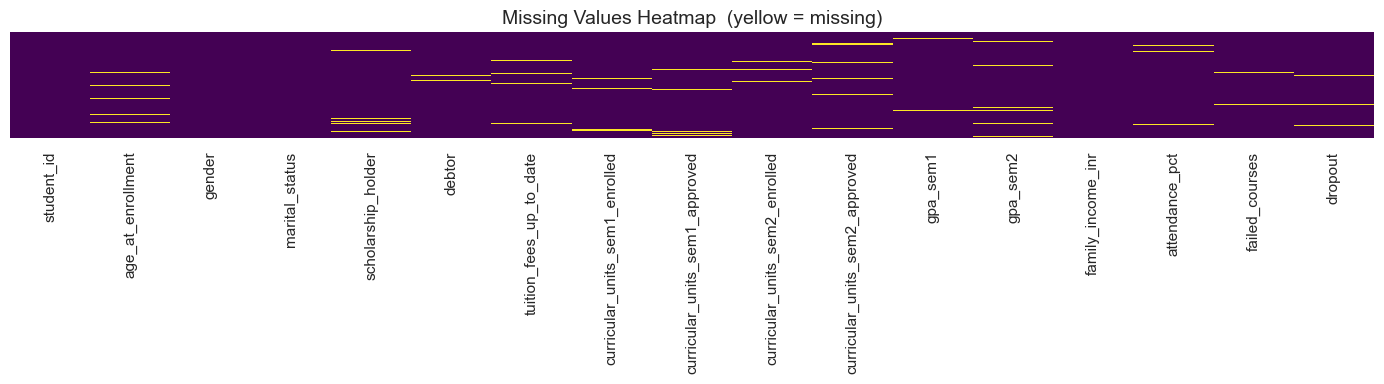

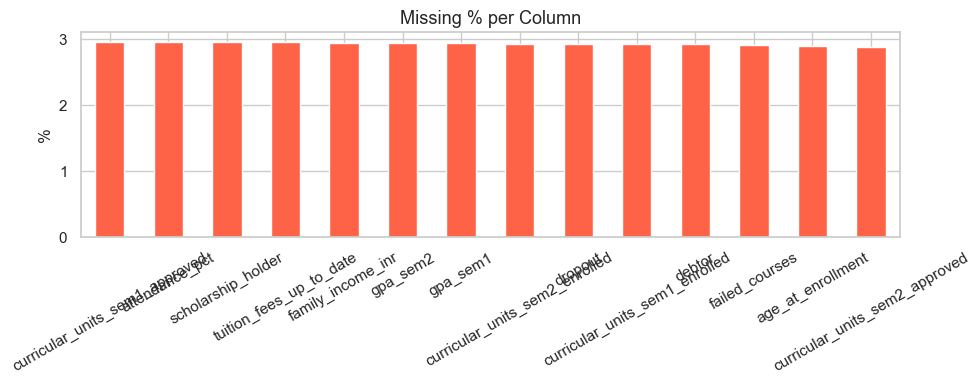

In [5]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 3 : MISSING VALUE ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct,
    'Data Type'    : df.dtypes,
    'Non-Null Count': df.notnull().sum()
}).sort_values('Missing %', ascending=False)

print("📌 Missing Values Table:")
display(missing_df)

cols_with_missing = missing_df[missing_df['Missing Count'] > 0].index.tolist()
print(f"\n⚠️  Columns with missing data: {len(cols_with_missing)}")
print(f"   Total missing cells: {missing_count.sum()} ({missing_count.sum()/df.size*100:.2f}% of all data)")

# Heatmap
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap  (yellow = missing)', fontsize=14)
plt.tight_layout(); plt.show()

# Bar chart
if cols_with_missing:
    plt.figure(figsize=(10, 4))
    missing_df[missing_df['Missing Count']>0]['Missing %'].plot(kind='bar', color='tomato', edgecolor='white')
    plt.title('Missing % per Column'); plt.ylabel('%'); plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()

---
## 🔧 Section 4 – Filling Missing Values

In [6]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 4 : FILLING MISSING VALUES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📖 Strategies for handling missing values:")
print("  1. Drop rows   → when missing % < 1% and rows are expendable")
print("  2. Mean fill   → for normally distributed numerics (skewness ≈ 0)")
print("  3. Median fill → for skewed numerics (robust to outliers)  ← USED HERE")
print("  4. Mode fill   → for categorical and discrete columns       ← USED HERE")
print("  5. KNN impute  → when relationships between features matter (advanced)")
print("  6. MICE / IterativeImputer → multivariate approach (advanced)")
print()

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Chosen method per column:")
for col in num_cols:
    if df[col].isnull().sum() > 0:
        skew = df[col].skew()
        method = "median" if abs(skew) > 0.5 else "mean"
        val = df[col].median() if method == "median" else df[col].mean()
        df[col] = df[col].fillna(val)
        print(f"  [NUMERIC]  {col}: skewness={skew:.2f} → filled with {method} ({val:.2f})")

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  [CATEG]    {col}: filled with mode = '{mode_val}'")

print(f"\n✅ Missing values remaining: {df.isnull().sum().sum()}")

📖 Strategies for handling missing values:
  1. Drop rows   → when missing % < 1% and rows are expendable
  2. Mean fill   → for normally distributed numerics (skewness ≈ 0)
  3. Median fill → for skewed numerics (robust to outliers)  ← USED HERE
  4. Mode fill   → for categorical and discrete columns       ← USED HERE
  5. KNN impute  → when relationships between features matter (advanced)
  6. MICE / IterativeImputer → multivariate approach (advanced)

Chosen method per column:
  [NUMERIC]  age_at_enrollment: skewness=0.09 → filled with mean (25.55)
  [NUMERIC]  scholarship_holder: skewness=0.27 → filled with mean (0.41)
  [NUMERIC]  debtor: skewness=0.44 → filled with mean (0.20)
  [NUMERIC]  tuition_fees_up_to_date: skewness=-1.06 → filled with median (1.00)
  [NUMERIC]  curricular_units_sem1_enrolled: skewness=0.09 → filled with mean (4.47)
  [NUMERIC]  curricular_units_sem1_approved: skewness=0.39 → filled with mean (3.26)
  [NUMERIC]  curricular_units_sem2_enrolled: skewness=0.17

---
## 🎯 Section 5 – Outlier Detection

📖 Outlier detection methods:
  1. IQR method  → Values below Q1-1.5*IQR or above Q3+1.5*IQR
  2. Z-score     → Values with |z| > 3
  3. Box plot    → Visual detection

📌 Outlier Summary (IQR + Z-Score):


,Column,Q1,Q3,IQR,Lower Fence,Upper Fence,IQR Outliers,IQR Outlier %,Z-Score Outliers
0,gpa_sem1,9.36,14.63,5.27,1.45,22.54,248,2.48,200
1,gpa_sem2,9.33,14.66,5.33,1.34,22.66,249,2.49,200
2,attendance_pct,61.95,88.85,26.90,21.59,129.21,246,2.46,202
3,family_income_inr,87567.75,413449.25,325881.50,-401254.50,902271.50,674,6.74,277
4,failed_courses,1.00,4.00,3.00,-3.50,8.50,200,2.00,200


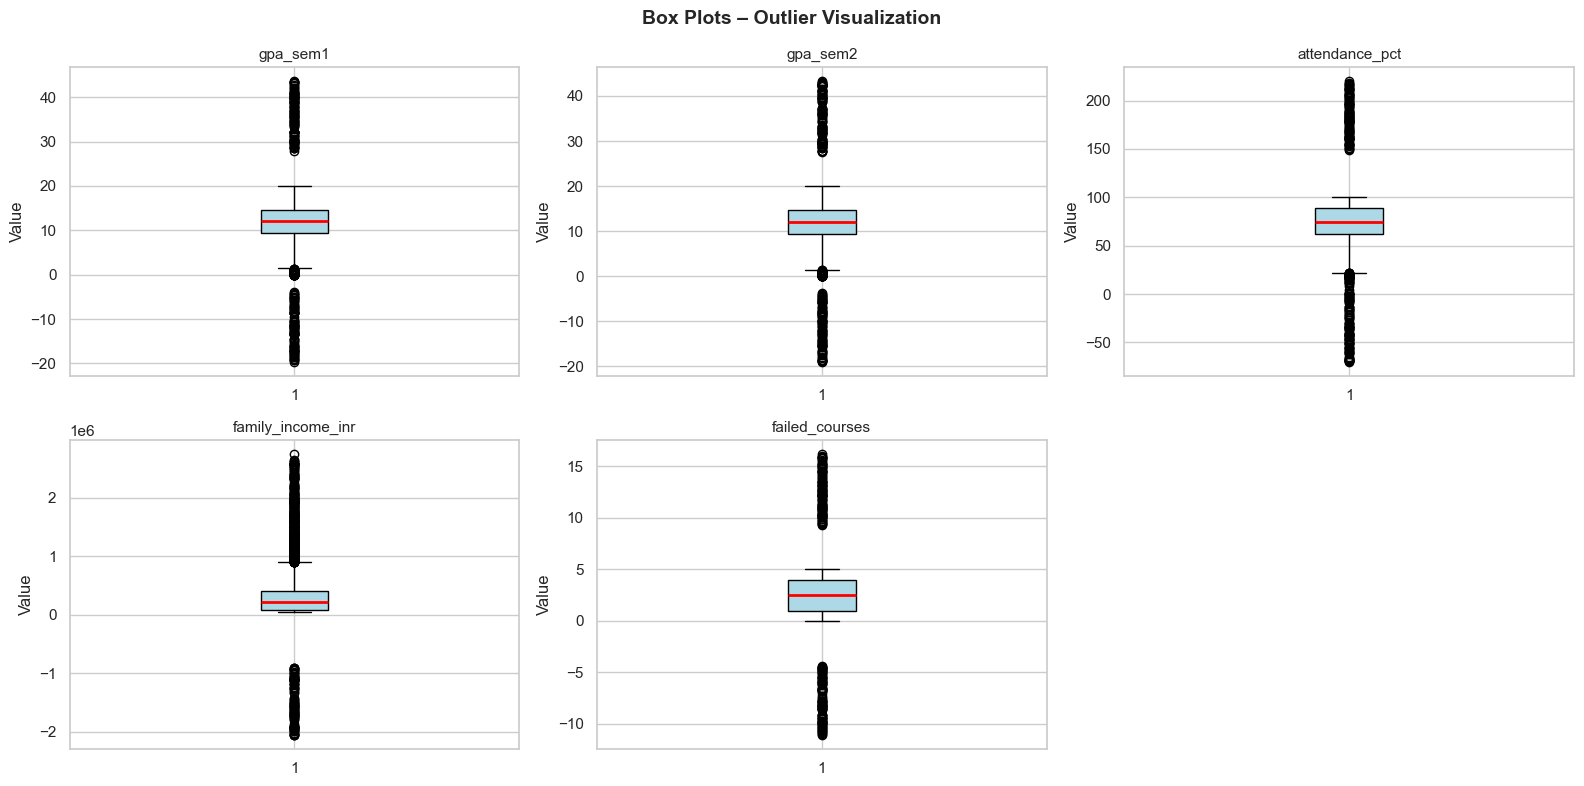

In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 5 : OUTLIER DETECTION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📖 Outlier detection methods:")
print("  1. IQR method  → Values below Q1-1.5*IQR or above Q3+1.5*IQR")
print("  2. Z-score     → Values with |z| > 3")
print("  3. Box plot    → Visual detection")
print()

check_cols = ['gpa_sem1', 'gpa_sem2', 'attendance_pct', 'family_income_inr', 'failed_courses']
check_cols = [c for c in check_cols if c in df.columns]

outlier_summary = []
for col in check_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    n_iqr = ((df[col] < lower) | (df[col] > upper)).sum()
    n_z   = (z_scores > 3).sum()
    outlier_summary.append({
        'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
        'Lower Fence': round(lower,2), 'Upper Fence': round(upper,2),
        'IQR Outliers': n_iqr, 'IQR Outlier %': round(n_iqr/len(df)*100,2),
        'Z-Score Outliers': n_z
    })

outlier_df = pd.DataFrame(outlier_summary)
print("📌 Outlier Summary (IQR + Z-Score):")
display(outlier_df)

# Box plots
n = len(check_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 4*rows))
axes = axes.flatten() if rows > 1 else [axes] if n == 1 else axes.flatten()
for i, col in enumerate(check_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue'), medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col}', fontsize=11)
    axes[i].set_ylabel('Value')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Box Plots – Outlier Visualization', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 🔨 Section 6 – Handling Outliers

In [8]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 6 : HANDLING OUTLIERS (IQR Capping)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📖 Outlier handling strategies:")
print("  1. Remove  → Drop outlier rows (risky if outliers are legitimate)")
print("  2. Cap     → Clip to IQR fences (Winsorization) ← USED HERE")
print("  3. Log transform → Compress extreme values for skewed data")
print("  4. Keep    → For fraud/anomaly detection (outliers = signal)")
print()

cap_cols = ['gpa_sem1', 'gpa_sem2', 'attendance_pct', 'family_income_inr', 'failed_courses']
cap_cols = [c for c in cap_cols if c in df.columns]
df_before = df.shape[0]

for col in cap_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"  {col}: capped {before} outliers to [{lower:.2f}, {upper:.2f}]")

print(f"\n✅ Dataset shape after outlier handling: {df.shape}")

📖 Outlier handling strategies:
  1. Remove  → Drop outlier rows (risky if outliers are legitimate)
  2. Cap     → Clip to IQR fences (Winsorization) ← USED HERE
  3. Log transform → Compress extreme values for skewed data
  4. Keep    → For fraud/anomaly detection (outliers = signal)

  gpa_sem1: capped 248 outliers to [1.45, 22.54]
  gpa_sem2: capped 249 outliers to [1.33, 22.66]
  attendance_pct: capped 246 outliers to [21.59, 129.21]
  family_income_inr: capped 674 outliers to [-401254.50, 902271.50]
  failed_courses: capped 200 outliers to [-3.50, 8.50]

✅ Dataset shape after outlier handling: (10000, 17)


---
## 📊 Section 7 – Univariate Analysis: Numeric

📌 Descriptive Stats for Numeric Features:
  age_at_enrollment: mean=25.554 | median=25.554 | std=6.727 | skew=0.087 | kurt=8.786
  gpa_sem1: mean=11.989 | median=12.002 | std=4.120 | skew=-0.053 | kurt=-0.015
  gpa_sem2: mean=11.950 | median=11.972 | std=4.095 | skew=-0.066 | kurt=0.030
  attendance_pct: mean=74.381 | median=74.710 | std=19.299 | skew=-0.295 | kurt=0.155
  failed_courses: mean=2.495 | median=2.497 | std=1.871 | skew=0.037 | kurt=0.264
  family_income_inr: mean=287250.051 | median=212012.000 | std=258336.090 | skew=0.900 | kurt=0.455
  curricular_units_sem1_approved: mean=3.264 | median=3.000 | std=3.545 | skew=0.393 | kurt=8.431
  curricular_units_sem2_approved: mean=3.188 | median=3.000 | std=3.552 | skew=0.086 | kurt=8.585


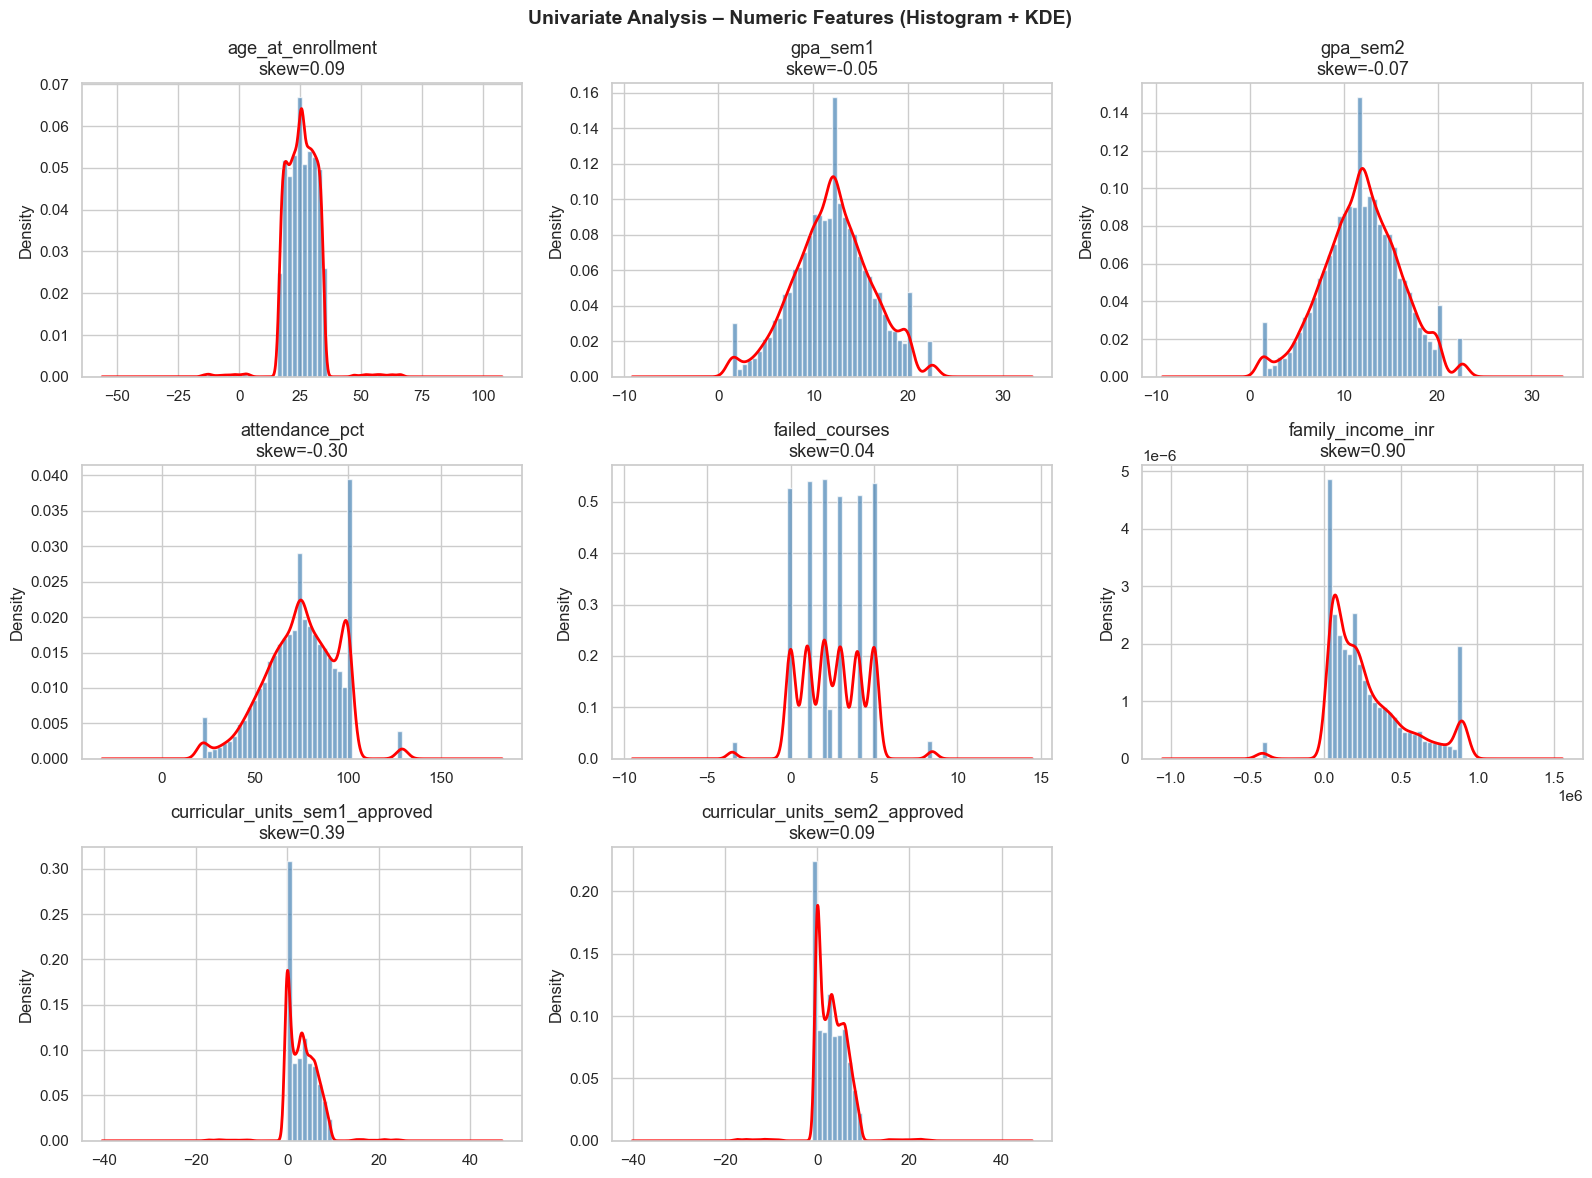

In [9]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 7 : UNIVARIATE – NUMERIC
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plot_num = ['age_at_enrollment', 'gpa_sem1', 'gpa_sem2', 'attendance_pct', 'failed_courses', 'family_income_inr', 'curricular_units_sem1_approved', 'curricular_units_sem2_approved']
exclude_cols = ['dropout']
plot_num = [c for c in plot_num if c in df.columns and c not in exclude_cols]

print("📌 Descriptive Stats for Numeric Features:")
for col in plot_num:
    print(f"  {col}: mean={df[col].mean():.3f} | median={df[col].median():.3f} | "
          f"std={df[col].std():.3f} | skew={df[col].skew():.3f} | kurt={df[col].kurt():.3f}")

# Histogram + KDE
n = len(plot_num)
rows = (n + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(16, 4*rows))
axes = axes.flatten()
for i, col in enumerate(plot_num):
    data = df[col].dropna()
    axes[i].hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white', density=True)
    data.plot.kde(ax=axes[i], color='red', linewidth=2)
    axes[i].set_title(f'{col}\nskew={data.skew():.2f}')
    axes[i].set_xlabel('')
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Univariate Analysis – Numeric Features (Histogram + KDE)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 📊 Section 8 – Univariate Analysis: Categorical


📌 gender (2 unique values):
gender
Female    50.07
Male      49.93

📌 marital_status (4 unique values):
marital_status
Single      59.94
Married     30.01
Divorced     6.82
Widowed      3.23


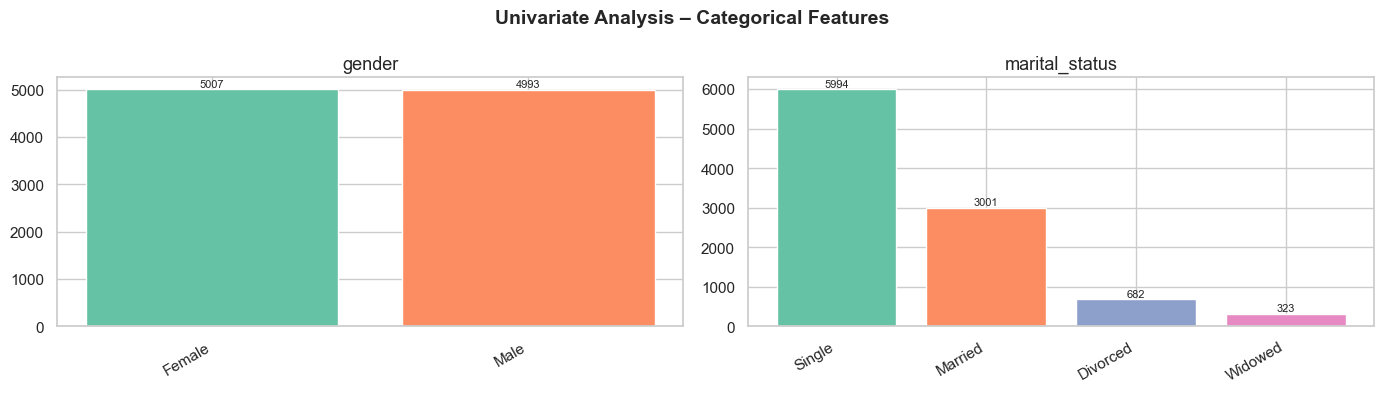

In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 8 : UNIVARIATE – CATEGORICAL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
plot_cat = ['gender', 'marital_status']
plot_cat = [c for c in plot_cat if c in df.columns]

for col in plot_cat:
    vc = df[col].value_counts()
    print(f"\n📌 {col} ({len(vc)} unique values):")
    print((vc / len(df) * 100).round(2).to_string())

if plot_cat:
    n = len(plot_cat)
    fig, axes = plt.subplots((n+1)//2, 2, figsize=(14, 4*((n+1)//2)))
    axes = axes.flatten()
    for i, col in enumerate(plot_cat):
        vc = df[col].value_counts().head(10)
        axes[i].bar(range(len(vc)), vc.values, color=sns.color_palette('Set2', len(vc)))
        axes[i].set_xticks(range(len(vc)))
        axes[i].set_xticklabels(vc.index, rotation=30, ha='right')
        axes[i].set_title(f'{col}')
        for x, v in enumerate(vc.values):
            axes[i].text(x, v + vc.values.max()*0.01, str(v), ha='center', fontsize=8)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('Univariate Analysis – Categorical Features', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 🎯 Section 9 – Column Importance Analysis

📌 Correlation of numeric features with target ('dropout'):
  age_at_enrollment: r = 0.0762
  gpa_sem1: r = -0.0047
  gpa_sem2: r = 0.0090
  attendance_pct: r = 0.0040
  failed_courses: r = 0.1552
  family_income_inr: r = -0.0045
  curricular_units_sem1_approved: r = -0.0040
  curricular_units_sem2_approved: r = 0.0087



📌 Feature Importance (Quick Random Forest):
gpa_sem1                          0.1602
gpa_sem2                          0.1596
attendance_pct                    0.1525
family_income_inr                 0.1425
age_at_enrollment                 0.1196
curricular_units_sem1_approved    0.0894
failed_courses                    0.0884
curricular_units_sem2_approved    0.0879


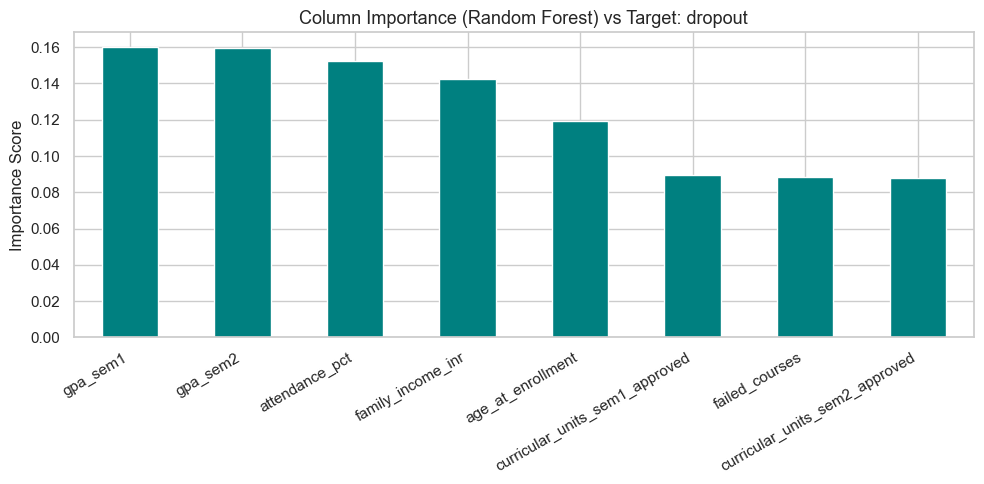

In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 9 : COLUMN IMPORTANCE (before modeling)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from sklearn.ensemble import RandomForestClassifier

feat_cols = ['age_at_enrollment', 'gpa_sem1', 'gpa_sem2', 'attendance_pct', 'failed_courses', 'family_income_inr', 'curricular_units_sem1_approved', 'curricular_units_sem2_approved']
feat_cols = [c for c in feat_cols if c in df.columns]

# Point-biserial / ANOVA correlation with target
print("📌 Correlation of numeric features with target ('dropout'):")
target_encoded = LabelEncoder().fit_transform(df['dropout'].astype(str)) if df['dropout'].dtype == 'object' else df['dropout']
for col in feat_cols:
    corr_val = df[col].corr(pd.Series(target_encoded, index=df.index))
    print(f"  {col}: r = {corr_val:.4f}")

# Quick Random Forest for importance
df_tmp = df[feat_cols + ['dropout']].dropna().copy()
df_tmp = df_tmp.dropna(subset=feat_cols).copy()
X_tmp = df_tmp[feat_cols]
y_tmp = df_tmp['dropout'].clip(0,1).round().astype(int)
le_tmp = LabelEncoder()
for c in X_tmp.select_dtypes(include='object').columns:
    X_tmp[c] = le_tmp.fit_transform(X_tmp[c].astype(str))
X_tmp = X_tmp.fillna(X_tmp.median())
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_imp.fit(X_tmp, y_tmp)
imp_series = pd.Series(rf_imp.feature_importances_, index=feat_cols).sort_values(ascending=False)
print("\n📌 Feature Importance (Quick Random Forest):")
print(imp_series.round(4).to_string())

plt.figure(figsize=(10, 5))
imp_series.plot(kind='bar', color='teal', edgecolor='white')
plt.title('Column Importance (Random Forest) vs Target: dropout')
plt.ylabel('Importance Score'); plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.show()

---
## 🔗 Section 10 – Bivariate Analysis

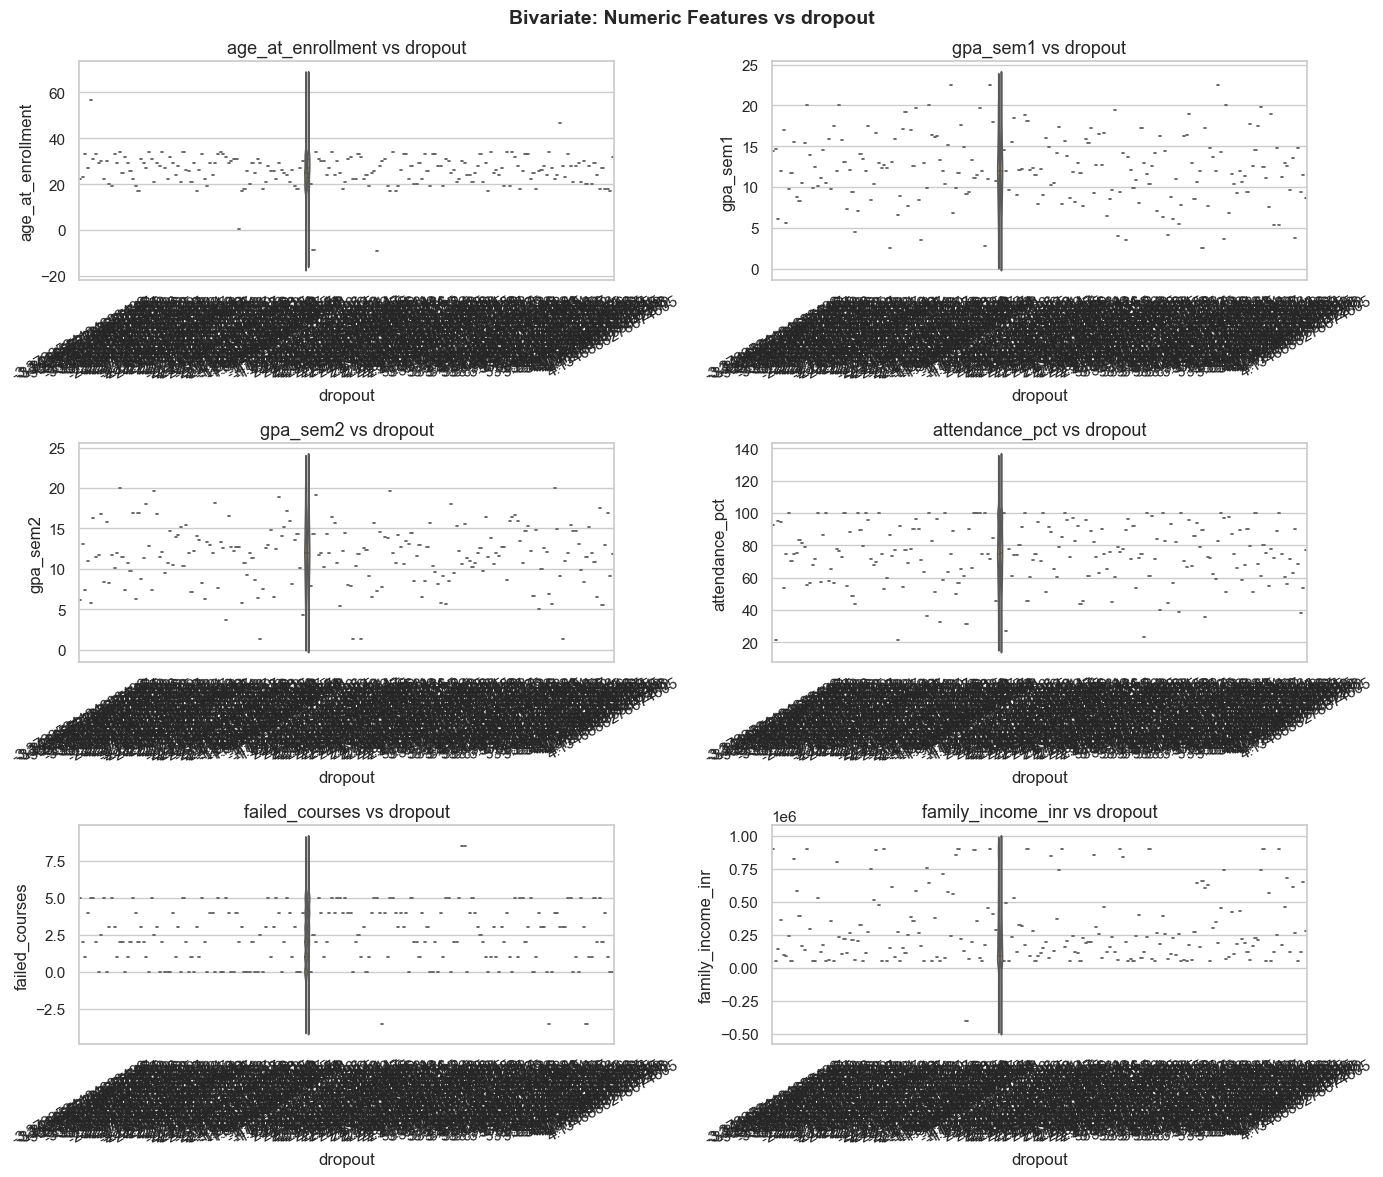

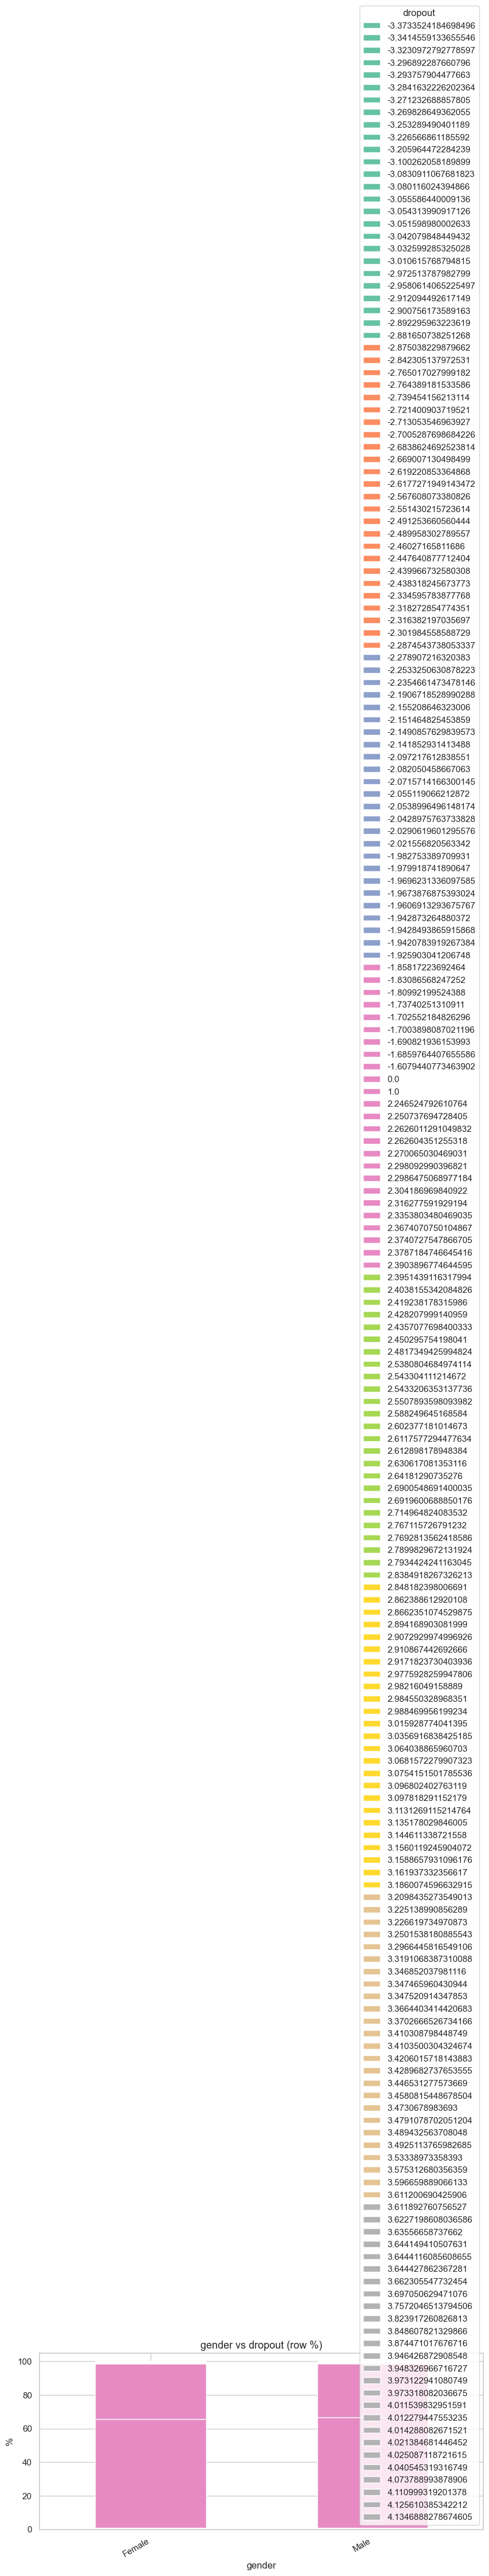

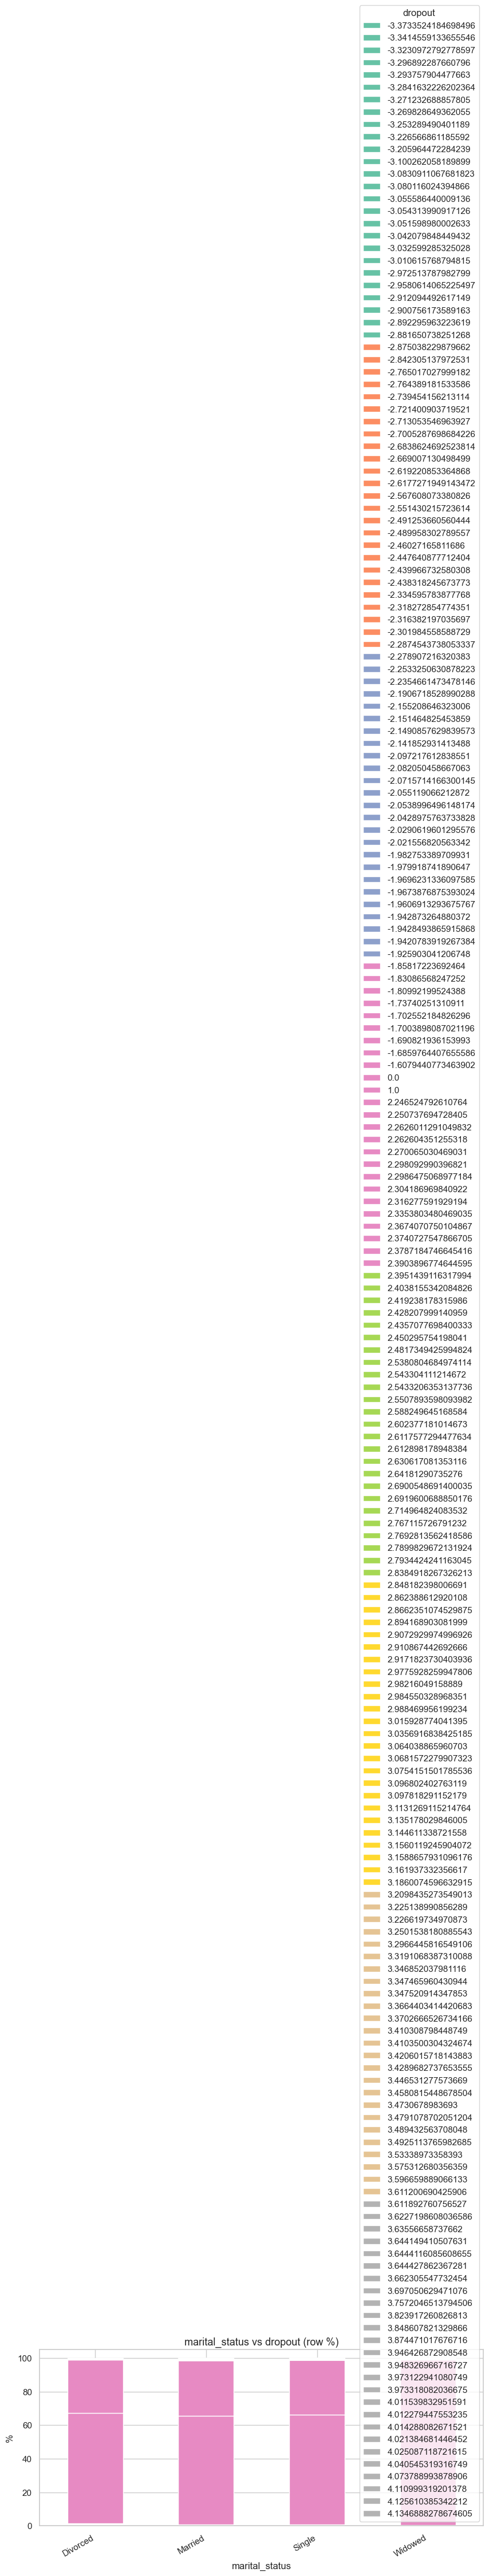

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 10 : BIVARIATE ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── Numeric vs Target (Box + Violin) ──
num_biv = ['age_at_enrollment', 'gpa_sem1', 'gpa_sem2', 'attendance_pct', 'failed_courses', 'family_income_inr']
num_biv = [c for c in num_biv if c in df.columns]
n = min(len(num_biv), 8)
rows = (n + 1) // 2
if n > 0:
    fig, axes = plt.subplots(rows, 2, figsize=(14, 4*rows))
    axes = axes.flatten() if rows > 1 else axes if n==1 else axes.flatten()
    for i, col in enumerate(num_biv[:n]):
        sns.violinplot(x='dropout', y=col, data=df, ax=axes[i], palette='Set2', inner='quartile')
        axes[i].set_title(f'{col} vs dropout')
        axes[i].tick_params(axis='x', rotation=30)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.suptitle('Bivariate: Numeric Features vs dropout', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

# ── Categorical vs Target (Stacked %) ──
cat_biv = ['gender', 'marital_status']
cat_biv = [c for c in cat_biv if c in df.columns and c != 'dropout']
for col in cat_biv[:4]:
    ct = pd.crosstab(df[col], df['dropout'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='Set2')
    plt.title(f'{col} vs dropout (row %)')
    plt.ylabel('%'); plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()

---
## 🌐 Section 11 – Multivariate Analysis

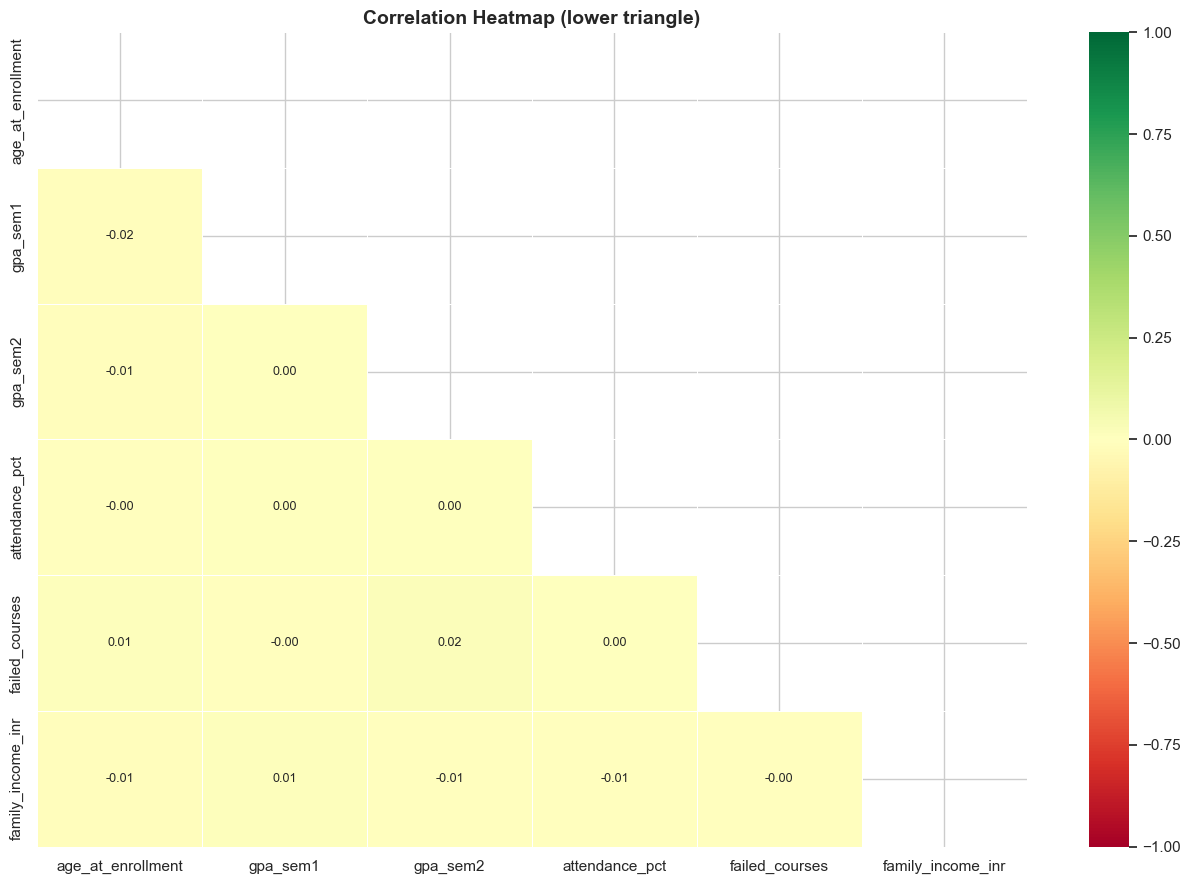

📌 Strong correlations (|r| > 0.6):


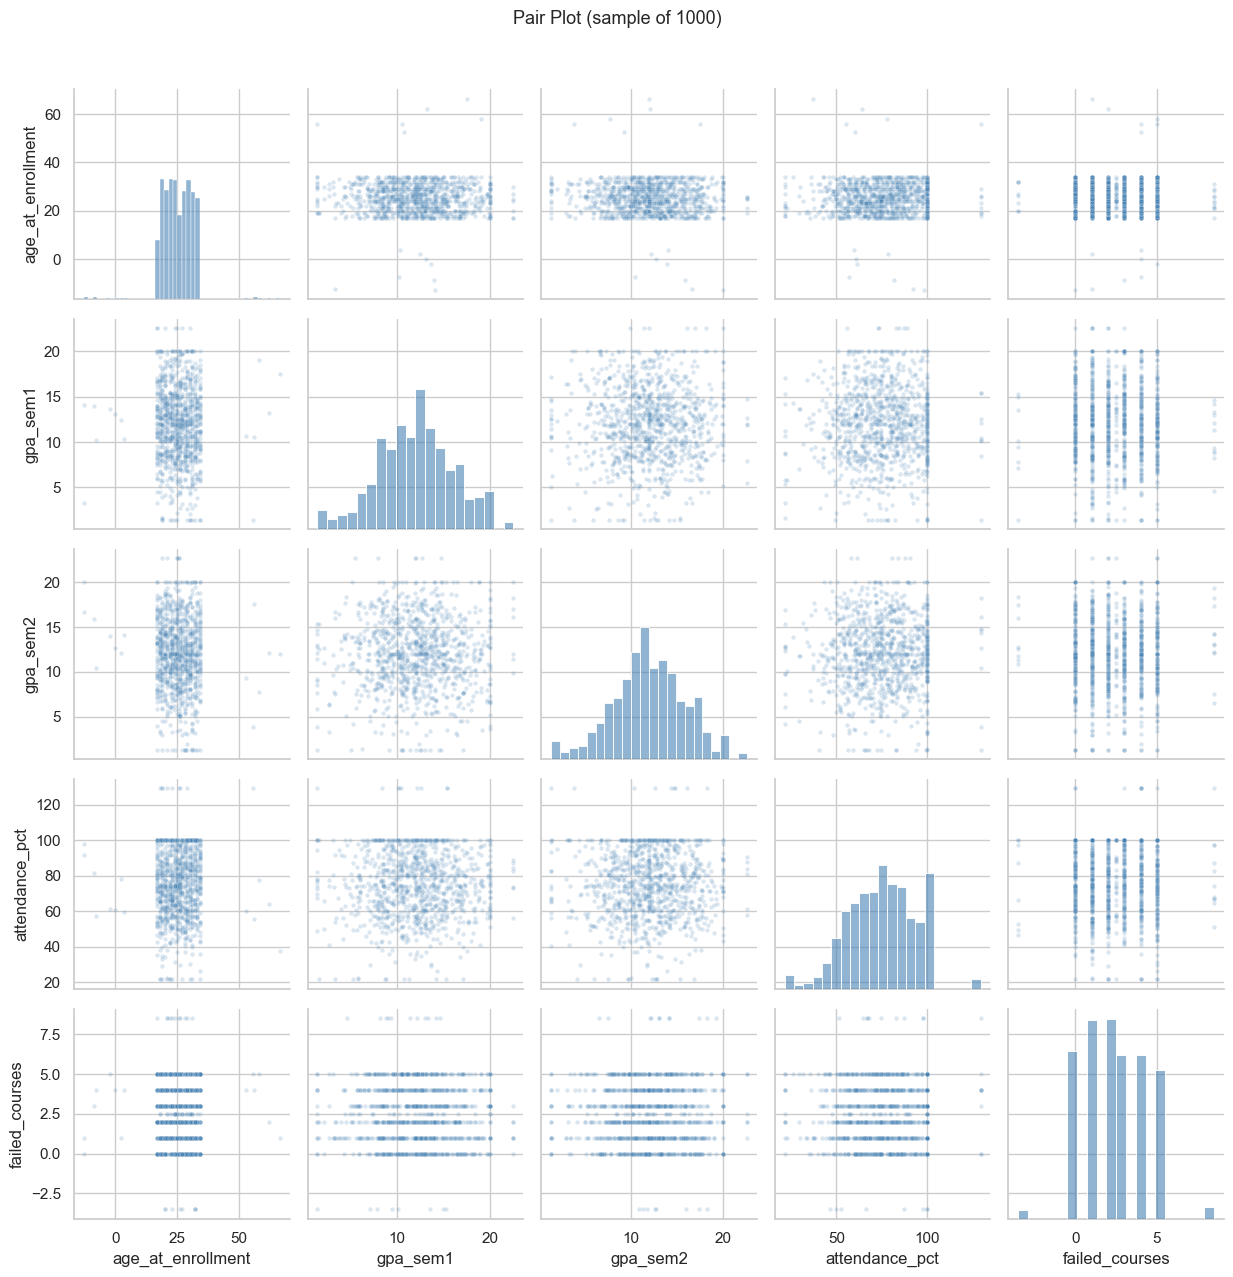

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 11 : MULTIVARIATE ANALYSIS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
multi_cols = ['age_at_enrollment', 'gpa_sem1', 'gpa_sem2', 'attendance_pct', 'failed_courses', 'family_income_inr']
multi_cols = [c for c in multi_cols if c in df.columns]

# Correlation heatmap
plt.figure(figsize=(13, 9))
corr = df[multi_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size':9}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Identify strong correlations
print("📌 Strong correlations (|r| > 0.6):")
for i in range(len(corr.columns)):
    for j in range(i):
        r = corr.iloc[i,j]
        if abs(r) > 0.6:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}: r = {r:.3f}")

# Pair plot (sample for speed)
sample_df = df[multi_cols[:5]].sample(min(1000, len(df)), random_state=42)
g = sns.PairGrid(sample_df)
g.map_diag(sns.histplot, color='steelblue', alpha=0.6)
g.map_offdiag(sns.scatterplot, alpha=0.2, s=10, color='steelblue')
plt.suptitle('Pair Plot (sample of 1000)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

---
## ⚙️ Section 12 – Preprocessing & Feature Engineering

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 12 : PREPROCESSING
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df_model = df.copy()
drop = ['student_id']
df_model.drop(columns=[c for c in drop if c in df_model.columns], inplace=True)

le = LabelEncoder()
enc_cols = ['gender', 'marital_status']
for col in enc_cols:
    if col in df_model.columns:
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# Encode remaining object columns
for col in df_model.select_dtypes(include='object').columns:
    if col != 'dropout':
        df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['dropout'])
y = df_model['dropout'].clip(0,1).round().astype(int)  # clamp noisy outliers back to 0/1
if y.dtype == 'object': y = le.fit_transform(y.astype(str))

print(f"Features: {X.shape[1]} | Target classes: {np.unique(y)}")
print(f"Class distribution:\n{pd.Series(y).value_counts().to_string()}")

scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
X_train_s = pd.DataFrame(X_train_s, columns=X.columns)
X_test_s  = pd.DataFrame(X_test_s,  columns=X.columns)
print(f"\n✅ Train: {X_train.shape} | Test: {X_test.shape}")

Features: 15 | Target classes: [0 1]
Class distribution:
dropout
0    6617
1    3383

✅ Train: (8000, 15) | Test: (2000, 15)


---
## 🤖 Section 13 – Model Training (4 Advanced Models)

In [15]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 13 : MODEL TRAINING  (4 Models)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import lightgbm as lgb_mod

scale_pos = 1
results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def train_clf(name, model, Xtr, ytr, Xte, yte, use_scaled=False):
    Xtr_ = X_train_s if use_scaled else Xtr
    Xte_ = X_test_s  if use_scaled else Xte
    cv_scores = cross_val_score(model, Xtr_, ytr, cv=skf, scoring='f1_weighted', n_jobs=-1)
    model.fit(Xtr_, ytr)
    pred  = model.predict(Xte_)
    proba = model.predict_proba(Xte_)[:,1] if len(np.unique(yte))==2 and hasattr(model,'predict_proba') else None
    results[name] = {
        'model': model,
        'accuracy' : accuracy_score(yte, pred),
        'precision': precision_score(yte, pred, average='weighted', zero_division=0),
        'recall'   : recall_score(yte, pred, average='weighted', zero_division=0),
        'f1'       : f1_score(yte, pred, average='weighted'),
        'roc_auc'  : roc_auc_score(yte, proba) if proba is not None else None,
        'cv_mean'  : cv_scores.mean(), 'cv_std': cv_scores.std(),
        'pred': pred, 'use_scaled': use_scaled
    }
    roc_str = f"  ROC-AUC={results[name]['roc_auc']:.4f}" if results[name]['roc_auc'] else ""
    print(f"  [{name}]  Acc={results[name]['accuracy']:.4f}  F1={results[name]['f1']:.4f}  "
          f"CV={cv_scores.mean():.4f}±{cv_scores.std():.3f}{roc_str}")

print("━"*60)
print("  Training Model 1: XGBoost Classifier")
print("━"*60)
train_clf('XGBoost', XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1),
    X_train, y_train, X_test, y_test)

print("\n━"*1+"━"*59)
print("  Training Model 2: LightGBM Classifier")
print("━"*60)
train_clf('LightGBM', LGBMClassifier(
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1),
    X_train, y_train, X_test, y_test)

print("\n━"*1+"━"*59)
print("  Training Model 3: CatBoost Classifier")
print("━"*60)
train_clf('CatBoost', CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.05,
    l2_leaf_reg=3, random_state=42, verbose=0),
    X_train, y_train, X_test, y_test)

print("\n━"*1+"━"*59)
print(f"  Training Model 4: GradientBoosting")
print("━"*60)
train_clf('GradientBoosting', GradientBoostingClassifier(n_estimators=300,max_depth=5,learning_rate=0.05,subsample=0.8,random_state=42),
    X_train, y_train, X_test, y_test, use_scaled=False)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training Model 1: XGBoost Classifier
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  [XGBoost]  Acc=0.8440  F1=0.8415  CV=0.8329±0.007  ROC-AUC=0.8999

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training Model 2: LightGBM Classifier
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  [LightGBM]  Acc=0.8360  F1=0.8329  CV=0.8327±0.005  ROC-AUC=0.8955

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training Model 3: CatBoost Classifier
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  [CatBoost]  Acc=0.8455  F1=0.8427  CV=0.8409±0.004  ROC-AUC=0.9079

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Training Model 4: GradientBoosting
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


  [GradientBoosting]  Acc=0.8390  F1=0.8363  CV=0.8366±0.005  ROC-AUC=0.9015


---
## 📈 Section 14 – Model Comparison

📌 Model Comparison Table:


,Accuracy,Precision,Recall,F1 Score,CV F1 Mean,CV F1 Std,ROC-AUC
Model,,,,,,,
CatBoost,0.8455,0.8434,0.8455,0.8427,0.8409,0.0037,0.9079
XGBoost,0.8440,0.8418,0.8440,0.8415,0.8329,0.0072,0.8999
GradientBoosting,0.8390,0.8366,0.8390,0.8363,0.8366,0.0049,0.9015
LightGBM,0.8360,0.8335,0.8360,0.8329,0.8327,0.0046,0.8955


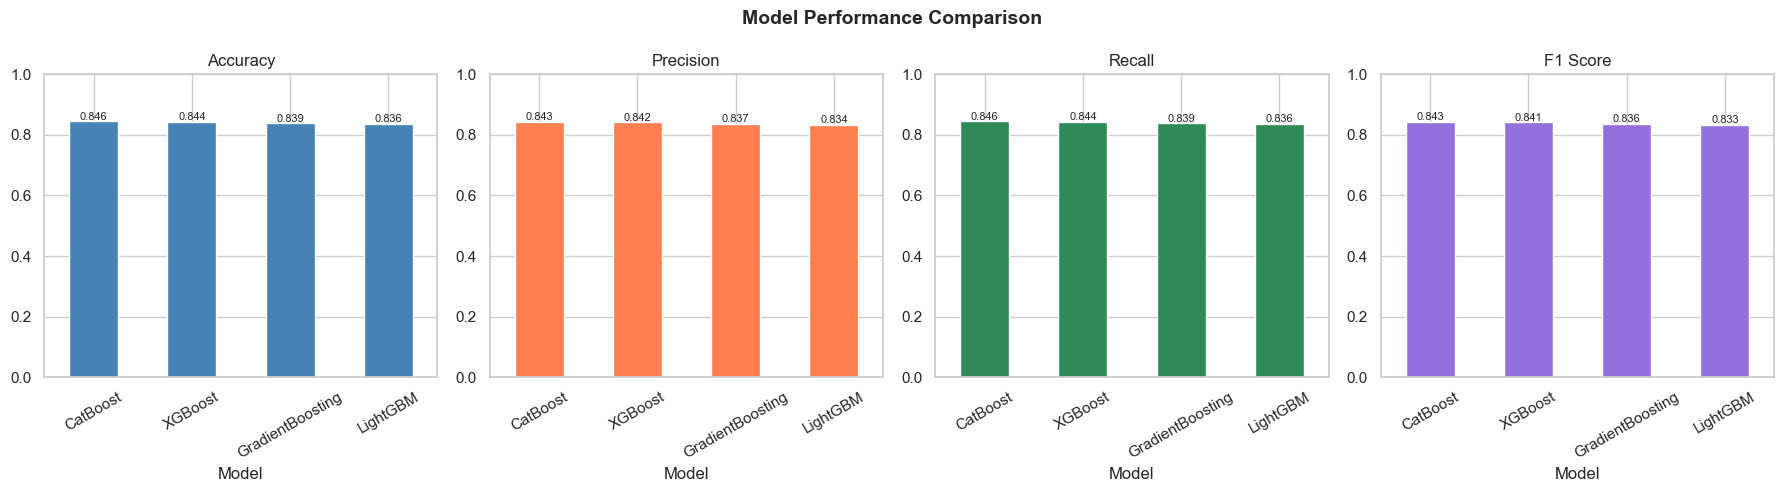


🏆 Best Model: CatBoost  |  F1=0.8427


In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 14 : MODEL COMPARISON
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
comp_rows = []
for name, v in results.items():
    row = {'Model': name, 'Accuracy': v['accuracy'], 'Precision': v['precision'],
           'Recall': v['recall'], 'F1 Score': v['f1'],
           'CV F1 Mean': v['cv_mean'], 'CV F1 Std': v['cv_std']}
    if v['roc_auc']: row['ROC-AUC'] = v['roc_auc']
    comp_rows.append(row)

comp_df = pd.DataFrame(comp_rows).sort_values('F1 Score', ascending=False)
print("📌 Model Comparison Table:")
display(comp_df.set_index('Model').round(4))

metrics = ['Accuracy','Precision','Recall','F1 Score']
fig, axes = plt.subplots(1, len(metrics), figsize=(18, 5))
colors = ['steelblue','coral','seagreen','mediumpurple']
for ax, metric, color in zip(axes, metrics, colors):
    comp_df.set_index('Model')[metric].plot(kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(metric, fontsize=12); ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x()+p.get_width()/2, p.get_height()+0.005),
                    ha='center', fontsize=8)
plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

best_name = comp_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_name}  |  F1={comp_df.iloc[0]['F1 Score']:.4f}")

---
## 📋 Section 15 – Detailed Report (Best Model)

📌 Classification Report – CatBoost:
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      1323
           1       0.81      0.71      0.76       677

    accuracy                           0.85      2000
   macro avg       0.84      0.81      0.82      2000
weighted avg       0.84      0.85      0.84      2000



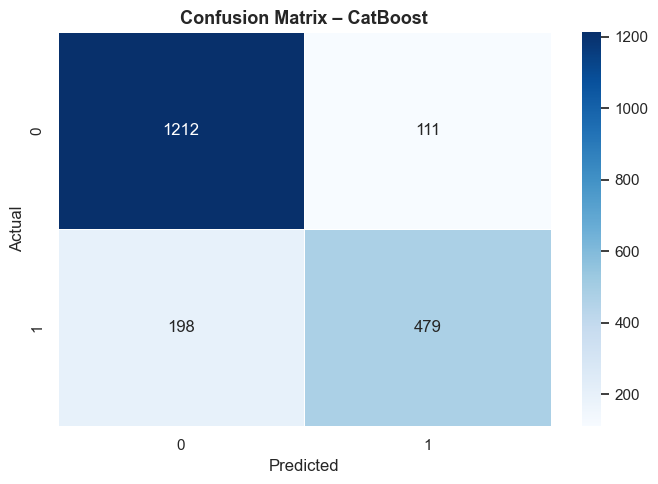

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 15 : DETAILED REPORT – BEST MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_model = results[best_name]['model']
best_pred  = results[best_name]['pred']

print(f"📌 Classification Report – {best_name}:")
print(classification_report(y_test, best_pred))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='white')
plt.title(f'Confusion Matrix – {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

---
## 🌟 Section 16 – Feature Importance

📌 Top Feature Importances:
debtor                            33.3493
tuition_fees_up_to_date           13.2929
scholarship_holder                13.2867
failed_courses                    12.2348
age_at_enrollment                  9.0239
gpa_sem2                           3.3084
attendance_pct                     2.8478
gpa_sem1                           2.5714
family_income_inr                  2.5423
curricular_units_sem1_enrolled     1.8629
curricular_units_sem2_approved     1.6361
curricular_units_sem2_enrolled     1.1061
marital_status                     1.0585
curricular_units_sem1_approved     0.9824
gender                             0.8965


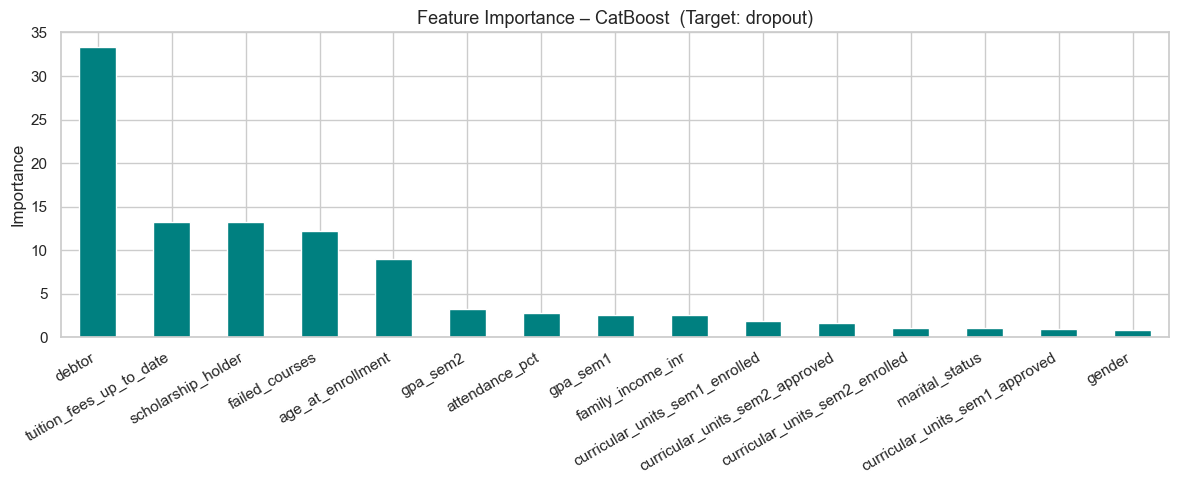

In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 16 : FEATURE IMPORTANCE (Best Model)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
try:
    fi = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print("📌 Top Feature Importances:")
    print(fi.round(4).to_string())
    fi.head(15).plot(kind='bar', color='teal', edgecolor='white', figsize=(12, 5))
    plt.title(f'Feature Importance – {best_name}  (Target: dropout)')
    plt.ylabel('Importance'); plt.xticks(rotation=30, ha='right')
    plt.tight_layout(); plt.show()
except AttributeError:
    print("Feature importance not available for this model type.")

---
## 💾 Section 17 – Save Best Model

In [19]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 17 : SAVE BEST MODEL
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model_path = r'D20_Student_Dropout_Prediction/dropout_predictor.pkl'
save_obj = {
    'model'     : best_model,
    'scaler'    : scaler,
    'features'  : list(X.columns),
    'best_name' : best_name,
    'score'     : comp_df.set_index('Model').loc[best_name].to_dict()
}
with open(model_path, 'wb') as f:
    pickle.dump(save_obj, f)

print(f"✅ Model saved to: {model_path}")
print(f"   Best Model : {best_name}")
print(f"   Features   : {len(X.columns)}")
print("\n📌 Comparison Table (Final):")
display(comp_df.set_index('Model').round(4))

✅ Model saved to: D20_Student_Dropout_Prediction/dropout_predictor.pkl
   Best Model : CatBoost
   Features   : 15

📌 Comparison Table (Final):


,Accuracy,Precision,Recall,F1 Score,CV F1 Mean,CV F1 Std,ROC-AUC
Model,,,,,,,
CatBoost,0.8455,0.8434,0.8455,0.8427,0.8409,0.0037,0.9079
XGBoost,0.8440,0.8418,0.8440,0.8415,0.8329,0.0072,0.8999
GradientBoosting,0.8390,0.8366,0.8390,0.8363,0.8366,0.0049,0.9015
LightGBM,0.8360,0.8335,0.8360,0.8329,0.8327,0.0046,0.8955
